In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("healthcare_patient_analytics_seaborn.csv")


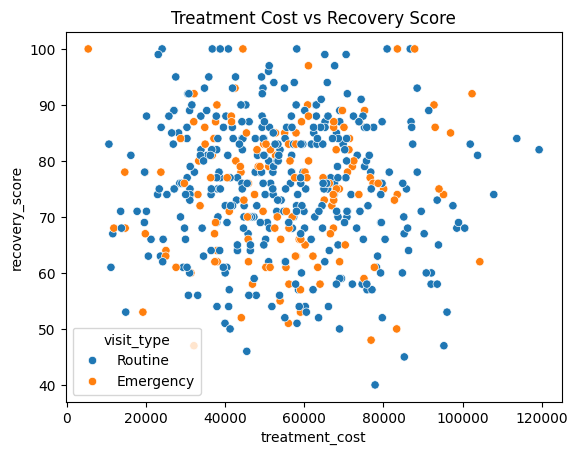

In [2]:
df=df.sample(500)
sns.scatterplot(
    data=df,
    x="treatment_cost",
    y="recovery_score",
    hue="visit_type"
)

plt.title("Treatment Cost vs Recovery Score")
plt.show()

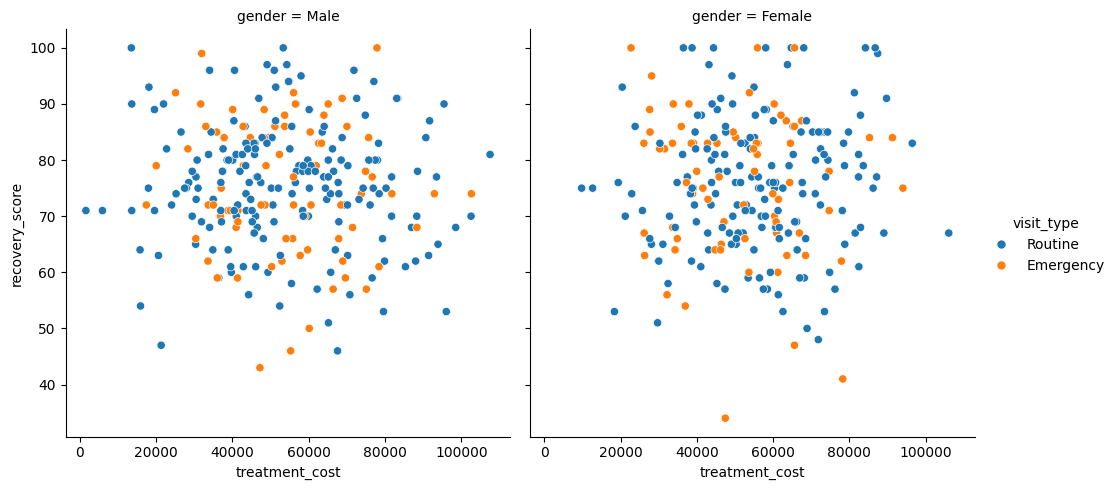

In [11]:
#eample figure relplot
sns.relplot(
    data=df,
    x="treatment_cost",
    y="recovery_score",
    hue="visit_type",
    col="gender"
)

In [12]:
#set theme in seaborn
sns.set_theme(style="whitegrid")

Text(0, 0.5, 'Recovery score')

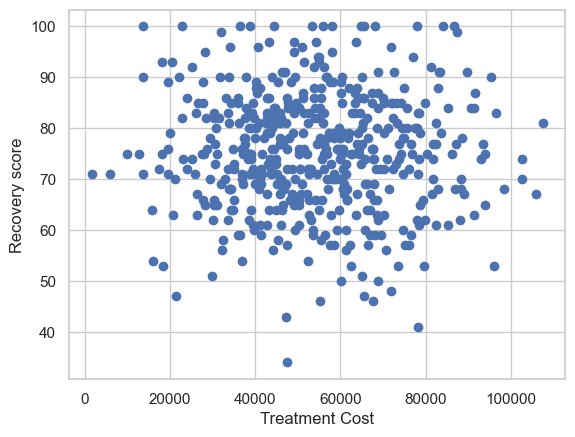

In [13]:
#reacreating matroplatlib and seaborn figure comperieion
plt.scatter(df['treatment_cost'], df['recovery_score'])
plt.xlabel("Treatment Cost")
plt.ylabel("Recovery score")

<Axes: xlabel='treatment_cost', ylabel='recovery_score'>

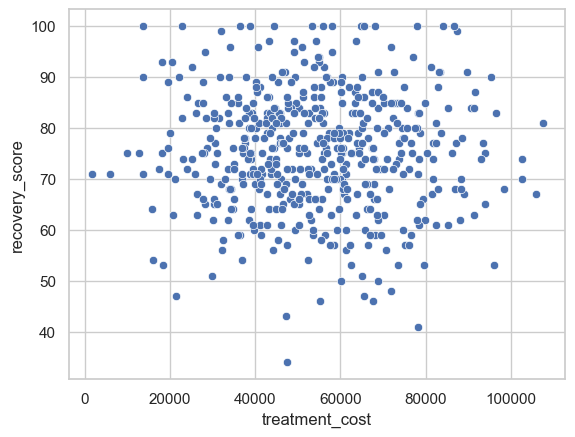

In [14]:
#seaborn figure
sns.scatterplot(
    data=df,
    x="treatment_cost",
    y="recovery_score"
)

Topic 78 | Distribution Plots - histplot & kdeplot

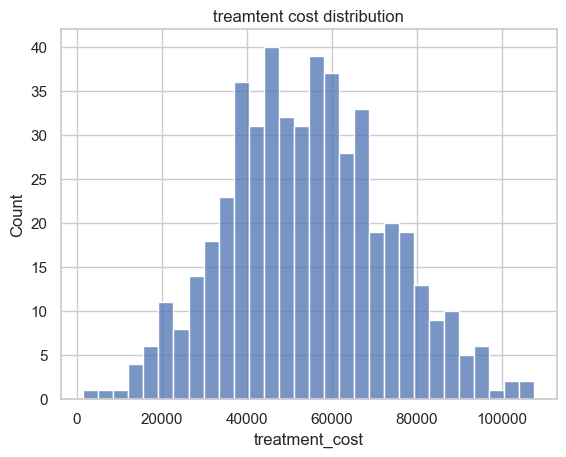

In [15]:
#histplot 
#treatment cost distribution
sns.histplot(
    data=df,
    x="treatment_cost",
    bins=30,
)
plt.title("treamtent cost distribution")
plt.show()

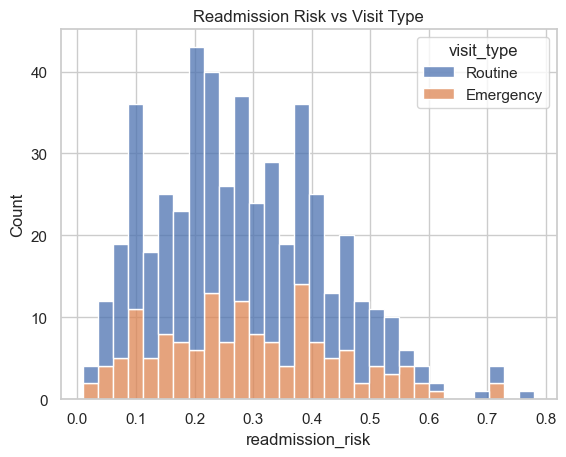

In [17]:
# routine vs emergency visit
sns.histplot(
    data=df,
    x="readmission_risk",
    hue="visit_type",
    multiple="stack",
    bins=30
)

plt.title("Readmission Risk vs Visit Type")
plt.show()

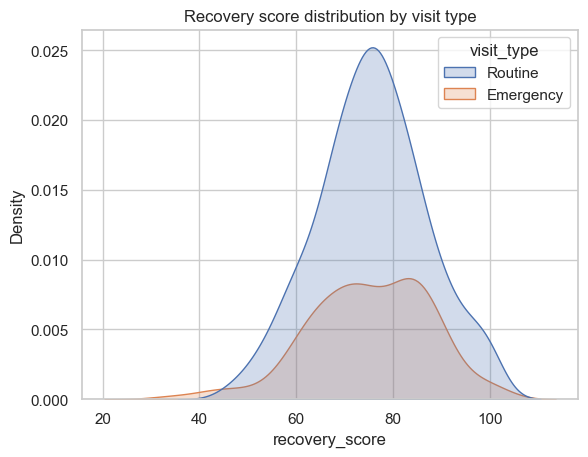

In [18]:
#kdeplot providing a smoothed curve of the distribution
sns.kdeplot(
    data=df,
    x="recovery_score",
    hue="visit_type",
    fill=True
)
plt.title("Recovery score distribution by visit type")
plt.show()

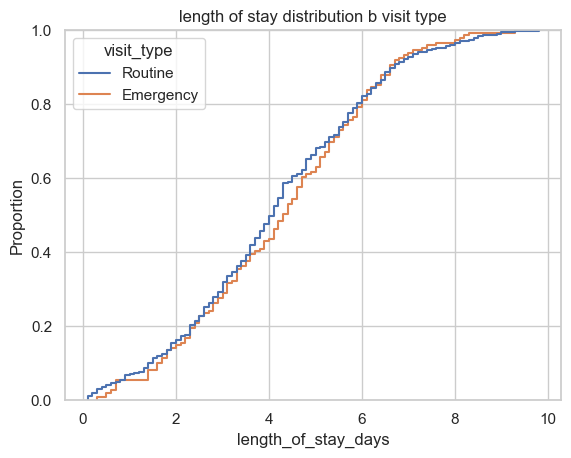

In [19]:
#ecdfplot showing the cumulative distribution of a variable
sns.ecdfplot(
    data=df,
    x="length_of_stay_days",
    hue="visit_type"
    
)
plt.title("length of stay distribution b visit type")
plt.show()

Topic 79 | Categorical Data Visualization with Seaborn

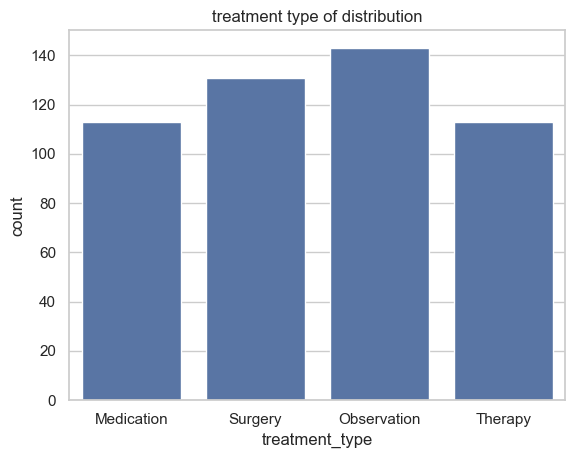

In [20]:
#counter plot
df=df.sample(500)
sns.countplot(
    data= df,
    x="treatment_type"
    
)
plt.title("treatment type of distribution")
plt.show()

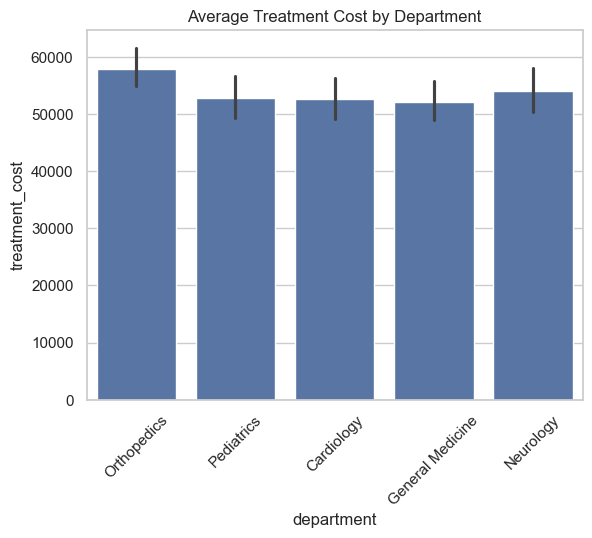

In [22]:
# barplot
sns.barplot(
    data=df,
    x="department",
    y="treatment_cost",
    estimator="mean"
)

plt.xticks(rotation=45)
plt.title("Average Treatment Cost by Department")
plt.show()

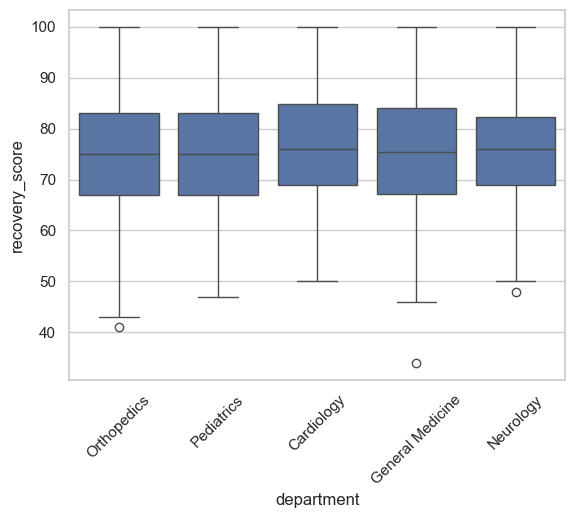

In [23]:
#boxplot show mean, median and outliers
sns.boxplot(
    data=df,
    x="department",
    y="recovery_score"
)
plt.xticks(rotation=45)
plt.show()

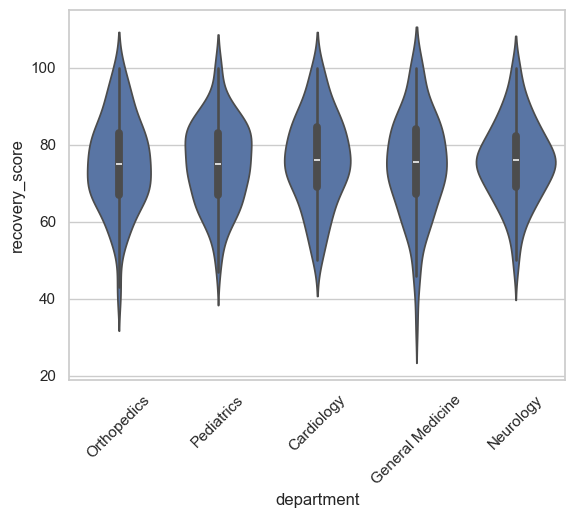

In [24]:
#volin plot show distribution and density of data
sns.violinplot(
    data=df,
    x="department",
    y="recovery_score"
)
plt.xticks(rotation=45)
plt.show()

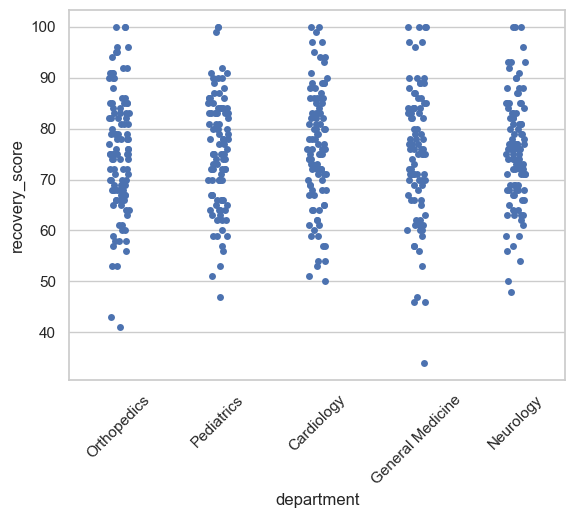

In [25]:
#stripplot show individual data points
sns.stripplot(
    data=df,
    x="department",
    y="recovery_score",
    jitter=True
)
plt.xticks(rotation=45)
plt.show()

Topic 80 | Heatmaps & Correlation Visualization

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("healthcare_patient_analytics_seaborn.csv")
numeric_df=df[
    ["treatment_cost", "recovery_score", "length_of_stay_days", "readmission_risk"]
]

In [27]:
#correlation matrix
corr_matrix=numeric_df.corr()
corr_matrix

,treatment_cost,recovery_score,length_of_stay_days,readmission_risk
treatment_cost,1.000000,-0.014562,-0.022281,0.017822
recovery_score,-0.014562,1.000000,0.012183,0.002052
length_of_stay_days,-0.022281,0.012183,1.000000,-0.000935
readmission_risk,0.017822,0.002052,-0.000935,1.000000


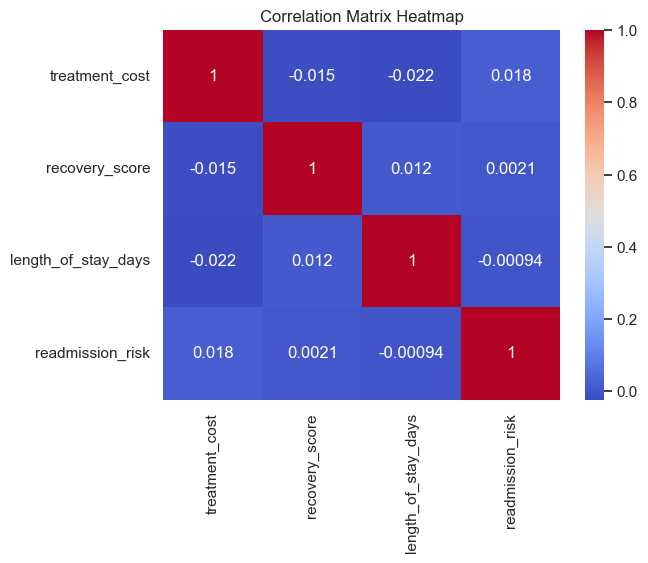

In [ ]:
#heatmap 
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"     #color scam
    
)
plt.title("Correlation Matrix Heatmap")
plt.show()

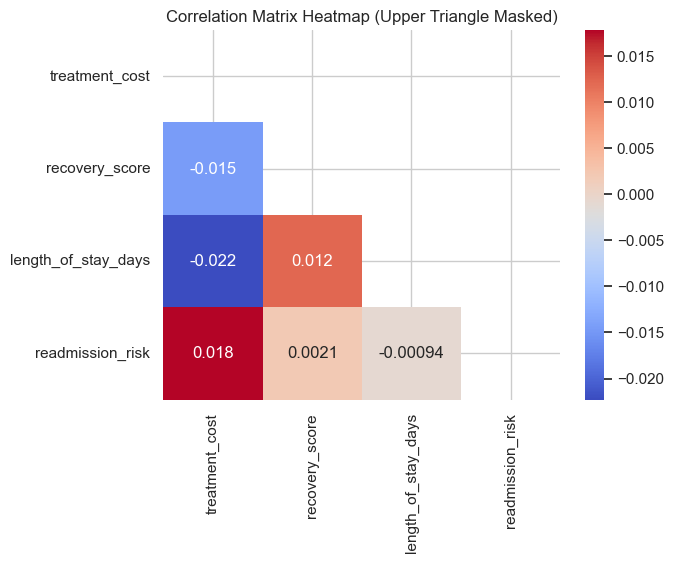

In [29]:
#masking upper triangle
import numpy as np
mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    mask=mask
)
plt.title("Correlation Matrix Heatmap (Upper Triangle Masked)")
plt.show()

Topic 81 | Encoding Categorical Variables

In [4]:
import pandas as pd

In [5]:
df=pd.DataFrame({
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'segment':['A', 'B', 'A', 'B', 'A'],
    'sales':[100, 150, 120, 130, 110]
})
print(df)

          city segment  sales
0     New York       A    100
1  Los Angeles       B    150
2      Chicago       A    120
3      Houston       B    130
4      Phoenix       A    110


In [6]:
#one hot encoding
encoded = pd.get_dummies(df,columns=["city","segment"], drop_first=True)
print(encoded)

   sales  city_Houston  city_Los Angeles  city_New York  city_Phoenix  \
0    100         False             False           True         False   
1    150         False              True          False         False   
2    120         False             False          False         False   
3    130          True             False          False         False   
4    110         False             False          False          True   

   segment_B  
0      False  
1       True  
2      False  
3       True  
4      False  


In [7]:
from sklearn.preprocessing import OrdinalEncoder
df2=pd.DataFrame({
    'education_level': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor']
})
print(df2)

  education_level
0     High School
1        Bachelor
2          Master
3             PhD
4        Bachelor


In [8]:
encoded2=OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
df2['education_level_encoded']=encoded2.fit_transform(df2[['education_level']])
print(df2)

  education_level  education_level_encoded
0     High School                      0.0
1        Bachelor                      1.0
2          Master                      2.0
3             PhD                      3.0
4        Bachelor                      1.0


Topic 82 | Feature Scaling & Normalization

In [9]:
import pandas as pd
import numpy as np
df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

In [ ]:
#inspect raw value
df[["monthly_income", "monthly_bill"]].head()

,monthly_income,monthly_bill
0,57643.0,10049.0
1,18207.0,2752.0
2,13075.0,3155.0
3,38890.0,5859.0
4,17475.0,5106.0


In [ ]:
#why scaling is required
df[["monthly_income", "monthly_bill"]].describe() #income dominate numerically model will focus on income

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


In [12]:
#z-score scaling standardization manual
#calculte mean ans std
income_mean=df['monthly_income'].mean()
income_std=df['monthly_income'].std()

print("mean", income_mean)
print("std",income_std)

mean 31155.975833333334
std 19351.937725889493


In [13]:
#2 apply z-scroe formula
df["monthly_income_zscore"]=(df["monthly_income"]-income_mean)/income_std
df[["monthly_income", "monthly_income_zscore"]].head()

,monthly_income,monthly_income_zscore
0,57643.0,1.368701
1,18207.0,-0.669131
2,13075.0,-0.934324
3,38890.0,0.399651
4,17475.0,-0.706956


In [14]:
# verify z-score scaling
df["monthly_income_zscore"].mean(), df["monthly_income_zscore"].std()

(np.float64(-1.628327102783563e-17), np.float64(0.9999999999999998))

In [15]:
#min-max scaling normalization
bill_min=df["monthly_bill"].min()
bill_max=df["monthly_bill"].max()

print("min", bill_min)
print("max", bill_max)

min 710.0
max 36361.0


In [16]:
#apply min-max scaling formula
df["monthly_bill_minmax"]=(df["monthly_bill"]-bill_min)/(bill_max-bill_min)
df[["monthly_bill", "monthly_bill_minmax"]].head()

,monthly_bill,monthly_bill_minmax
0,10049.0,0.261956
1,2752.0,0.057277
2,3155.0,0.068582
3,5859.0,0.144428
4,5106.0,0.123306


In [17]:
#verfiy min-max scaling
df["monthly_bill_minmax"].min(), df["monthly_bill_minmax"].max()

(np.float64(0.0), np.float64(1.0))

In [19]:
# show minimum and maximum value and mid value togather
df.loc[
    [
        df["monthly_bill"].idxmin(),
        df["monthly_bill"].idxmax(),
        df["monthly_bill"].sort_values().index[len(df)//2]
    ],
    ["monthly_bill", "monthly_bill_minmax"]
]

,monthly_bill,monthly_bill_minmax
893,710.0,0.000000
968,36361.0,1.000000
47,4873.0,0.116771


In [20]:
#side by side compersion
df[["monthly_income", "monthly_income_zscore", "monthly_bill", "monthly_bill_minmax"]].head()

,monthly_income,monthly_income_zscore,monthly_bill,monthly_bill_minmax
0,57643.0,1.368701,10049.0,0.261956
1,18207.0,-0.669131,2752.0,0.057277
2,13075.0,-0.934324,3155.0,0.068582
3,38890.0,0.399651,5859.0,0.144428
4,17475.0,-0.706956,5106.0,0.123306


In [21]:
# data leakage and wrong scaling (before split)
df_scaled_wrong=(df["monthly_income"]-df["monthly_income"].mean())/df["monthly_income"].std()
df_scaled_wrong.head()

0    1.368701
1   -0.669131
2   -0.934324
3    0.399651
4   -0.706956
Name: monthly_income, dtype: float64

Topic 83 | Feature Transformations


In [22]:
import pandas as pd
import numpy as np
df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

In [23]:
#see problem
df[["monthly_income", "monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


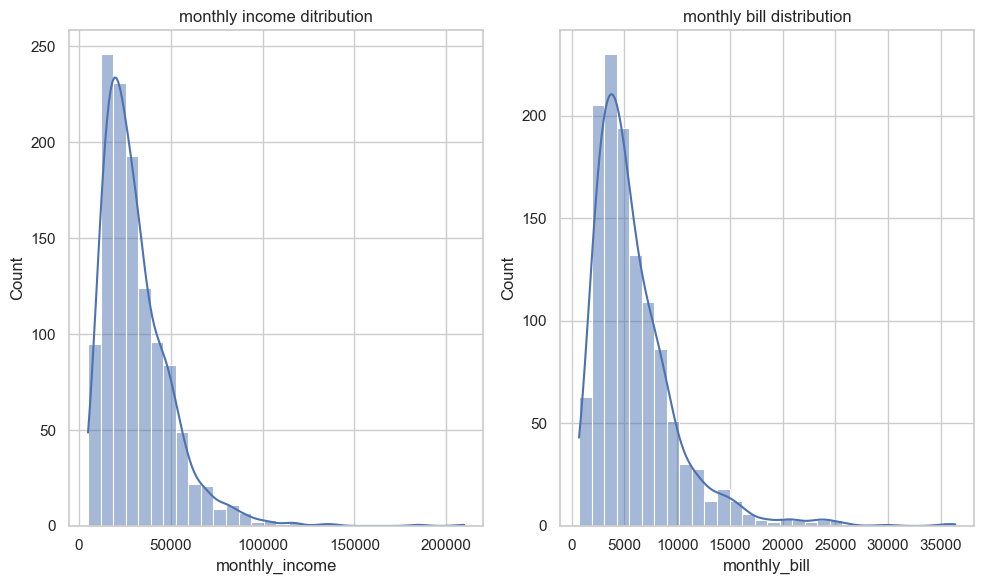

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(df["monthly_income"],kde=True, bins=30)
plt.title("monthly income ditribution")

plt.subplot(1,2,2)
sns.histplot(df["monthly_bill"],kde=True, bins=30)
plt.title("monthly bill distribution")
plt.tight_layout()
plt.show()

In [25]:
#safe log transformation
df["income_log"]=np.log1p(df["monthly_income"])
df[["monthly_income", "income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


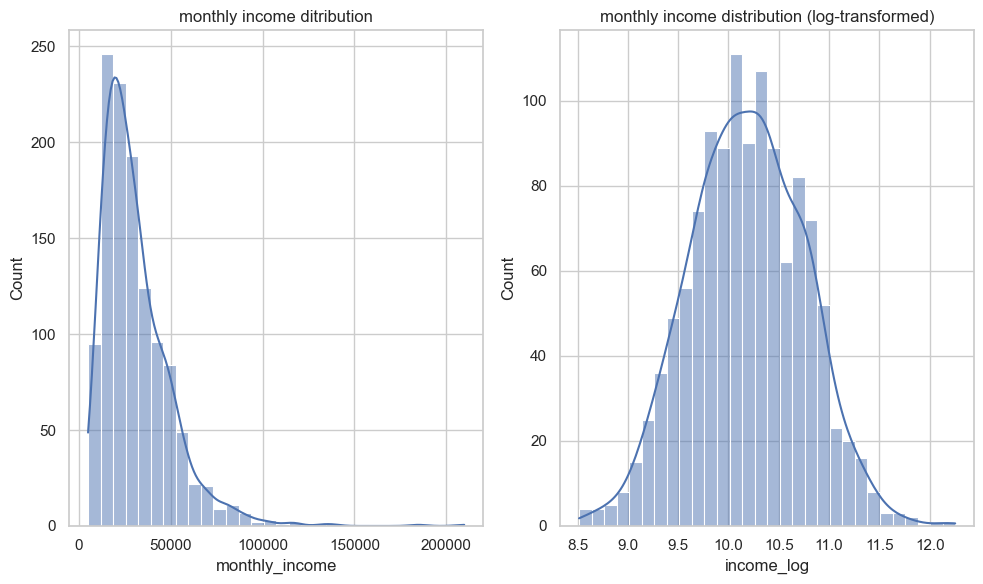

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(df["monthly_income"],kde=True, bins=30)
plt.title("monthly income ditribution")

plt.subplot(1,2,2)
sns.histplot(df["income_log"],kde=True, bins=30)
plt.title("monthly income distribution (log-transformed)")
plt.tight_layout()
plt.show()

In [27]:
#before vs after
df[["monthly_income", "income_log"]].describe()

,monthly_income,income_log
count,1200.000000,1200.000000
mean,31155.975833,10.185955
std,19351.937726,0.566190
min,4984.000000,8.514189
25%,17795.000000,9.786729
50%,26628.000000,10.189755
75%,39886.250000,10.593811
max,209790.000000,12.253867


In [28]:
#clipping
upper_limit=df["monthly_income"].quantile(0.99)
df["bill_clipped"]=df["monthly_income"].clip(upper=upper_limit)

df.loc[
    [
            df["monthly_income"].idxmax(),
            df["monthly_income"].sort_values().index[len(df)//2]
        ],
        ["monthly_income", "bill_clipped"]
    ]


,monthly_income,bill_clipped
129,209790.0,93218.87
1079,26665.0,26665.00


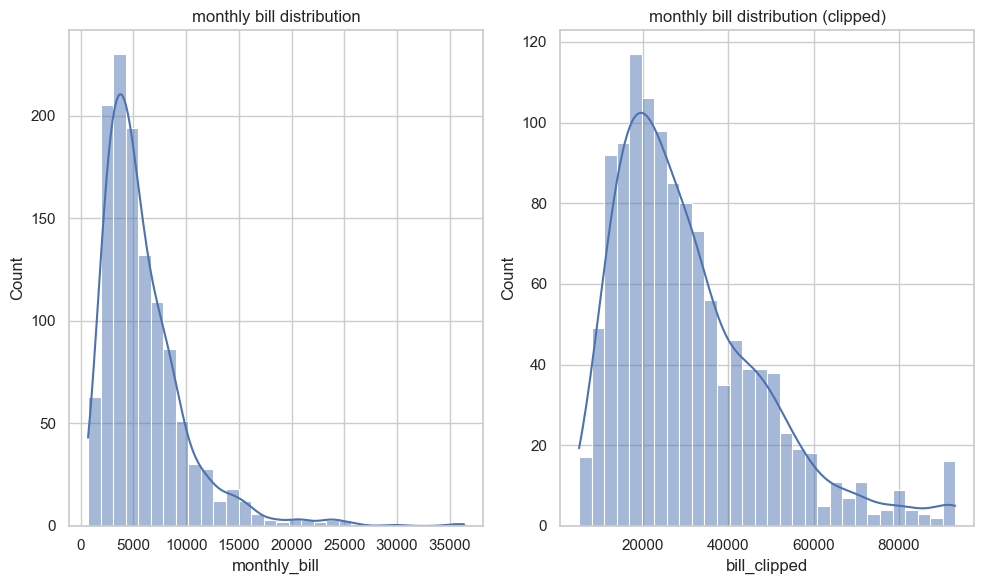

In [29]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(df["monthly_bill"],kde=True, bins=30)
plt.title("monthly bill distribution")

plt.subplot(1,2,2)
sns.histplot(df["bill_clipped"],kde=True, bins=30)
plt.title("monthly bill distribution (clipped)")
plt.tight_layout()
plt.show()

In [31]:
from scipy.stats.mstats import winsorize

# cap only top 10% of data
df["bill_winsorized"] = winsorize(
    df["monthly_bill"],
    limits=[0, 0.1]
)

# check effect on extreme values
df.loc[
    [
        df["monthly_bill"].idxmax(),
        df["monthly_bill"].idxmin(),
    ],
    ["monthly_bill", "bill_winsorized"]
]

,monthly_bill,bill_winsorized
968,36361.0,10613.0
893,710.0,710.0


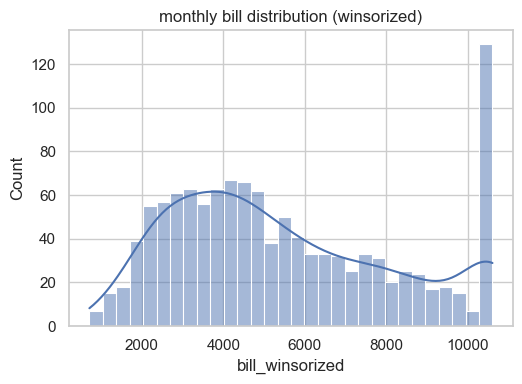

In [32]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,2)
sns.histplot(df["bill_winsorized"],kde=True, bins=30)
plt.title("monthly bill distribution (winsorized)")
plt.tight_layout()
plt.show()

Topic 84 | Creating New Features from Existing Data

In [33]:
import pandas as pd
import numpy as np
df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

In [34]:
#data part extreaction
df['signup_date']=pd.to_datetime(df['signup_date'])
df['signup_year']=df['signup_date'].dt.year
df["signup_month"]=df['signup_date'].dt.month
df["signup_dow"]=df['signup_date'].dt.dayofweek
df[["signup_date", "signup_year", "signup_month", "signup_dow"]].head()

,signup_date,signup_year,signup_month,signup_dow
0,2019-01-01,2019,1,1
1,2019-01-02,2019,1,2
2,2019-01-03,2019,1,3
3,2019-01-04,2019,1,4
4,2019-01-05,2019,1,5


In [35]:
#Ratio feature creation
df["income_to_bill_ratio"]=df["monthly_income"]/df["monthly_bill"]
df[["monthly_income", "monthly_bill", "income_to_bill_ratio"]].head()

,monthly_income,monthly_bill,income_to_bill_ratio
0,57643.0,10049.0,5.736193
1,18207.0,2752.0,6.615916
2,13075.0,3155.0,4.144216
3,38890.0,5859.0,6.637651
4,17475.0,5106.0,3.422444


In [36]:
#intraction feature
df["support_bill_intraction"]=(df["support_tickets"]*df["monthly_bill"])
df[["support_tickets", "monthly_bill", "support_bill_intraction"]].head()

,support_tickets,monthly_bill,support_bill_intraction
0,1,10049.0,10049.0
1,2,2752.0,5504.0
2,0,3155.0,0.0
3,2,5859.0,11718.0
4,0,5106.0,0.0


In [37]:
#text length feature

df["feedback_length"]=df["customer_feedback"].str.len()
df[["customer_feedback", "feedback_length"]].head()

,customer_feedback,feedback_length
0,Coverage is poor in my location,31
1,Billing issues occurred multiple times,38
2,Billing issues occurred multiple times,38
3,Customer support was helpful,28
4,Coverage is poor in my location,31


In [38]:
#keyword flag feature
df["complaint_flag"]=df["customer_feedback"].str.contains("slow|poor|expensive|drop|unreliable", case=False, na=False).astype(int)
df[["customer_feedback", "complaint_flag"]].head()

,customer_feedback,complaint_flag
0,Coverage is poor in my location,1
1,Billing issues occurred multiple times,0
2,Billing issues occurred multiple times,0
3,Customer support was helpful,0
4,Coverage is poor in my location,1


In [39]:
#final feature review
df[[
    "signup_year", "signup_month", "signup_dow",
    "income_to_bill_ratio",
    "support_bill_intraction",
    "feedback_length",
    "complaint_flag"
]].head()

,signup_year,signup_month,signup_dow,income_to_bill_ratio,support_bill_intraction,feedback_length,complaint_flag
0,2019,1,1,5.736193,10049.0,31,1
1,2019,1,2,6.615916,5504.0,38,0
2,2019,1,3,4.144216,0.0,38,0
3,2019,1,4,6.637651,11718.0,28,0
4,2019,1,5,3.422444,0.0,31,1


Topic 86 | Train-Test Split & Data Leakage Prevention

In [40]:
import pandas as pd
import numpy as np
df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

In [41]:
len(df)

1200

we will split into : 960 training row (80%) and 240 testing row(20%)

In [42]:
#random split using pandas
df_shuffled=df.sample(frac=1, random_state=42)
train_size=int(0.8 * len(df_shuffled))
train_df=df_shuffled[:train_size]
test_df=df_shuffled[train_size:]
len(train_df), len(test_df)

(960, 240)

In [43]:
#verfy no overlap
set(train_df.index).intersection(set(test_df.index))

set()

In [44]:
#leakage example wrong practices
#scaling before split
income_mean=df['monthly_income'].mean()
income_std=df['monthly_income'].std()
df["income_scaled_wrong"]=(df["monthly_income"]-income_mean)/income_std
df[["monthly_income", "income_scaled_wrong"]].head()

,monthly_income,income_scaled_wrong
0,57643.0,1.368701
1,18207.0,-0.669131
2,13075.0,-0.934324
3,38890.0,0.399651
4,17475.0,-0.706956


In [ ]:
#what went wrong
#text data influenced mean & std
#model indrectly "saw the feature"
#correct approache split data first then scale
#compute mean and std on training data only
#apply same value on text data


In [45]:
#sppearter feature aur target
x_train=train_df.drop("churn", axis=1)
y_train=train_df["churn"]

x_test=test_df.drop("churn", axis=1)
y_test=test_df["churn"]

x_train.shape, x_test.shape

((960, 14), (240, 14))